# Notebook 04 — LLM-basierte Verspätungsgrund-Hypothesen

**SBB Tracker · ZHAW Scientific Programming FS2026**
Joël Hasler & Patrick Ferreira

Die offiziellen SBB-Daten enthalten **keine** Verspätungs-Gründe — nur
Soll- und Ist-Zeiten. Trotzdem wäre es wertvoll, die "schlimmsten Tage"
qualitativ erklären zu können ("War das Wetter? Streckenarbeiten? Ein
Unfall?").

Hier nutzen wir ein **Large Language Model (Anthropic Claude Sonnet 4.6)**
als qualitativen Klassifikator: Wir geben ihm pro Tag den verfügbaren
Kontext (top betroffene Bahnhöfe, Wetter, Wochentag, Uhrzeit-Pattern)
und lassen es aus einer fixen Taxonomie eine Hypothese ableiten.

**Wichtig**: Das Modell kennt die Realität nicht — es **hypothetisiert**
plausible Ursachen aus dem Kontext. Limitations am Ende ausführlich
diskutiert.

Dieses Notebook deckt Bonus #4 (LLM-Nutzung) der Bewertungsrubrik ab.


## Bibliotheken und Einstellungen


In [1]:
# Bibliotheken und Einstellungen
import os
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(color_codes=True)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Aktuelles Verzeichnis:", os.getcwd())
print("Projekt-Root:", PROJECT_ROOT)


Aktuelles Verzeichnis: C:\Users\hasle\Documents\Scientific Programming\SBB Tracker\project\notebooks
Projekt-Root: C:\Users\hasle\Documents\Scientific Programming\SBB Tracker\project


In [2]:
import json
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv(PROJECT_ROOT / ".env")
api_key = os.getenv("ANTHROPIC_API_KEY")
model_name = os.getenv("ANTHROPIC_MODEL", "claude-sonnet-4-6")
if not api_key:
    raise ValueError("Missing ANTHROPIC_API_KEY in .env")
print(f"LLM-Modell: {model_name}")
print(f"API-Key sichtbar: True (endet auf ...{api_key[-4:]})")

client = Anthropic()  # liest ANTHROPIC_API_KEY automatisch


LLM-Modell: claude-sonnet-4-6
API-Key sichtbar: True (endet auf ...DgAA)


## Datensatz laden


In [3]:
df = pd.read_parquet(DATA_PROCESSED / "delays_prepared.parquet")
print(f"Geladen: {len(df):,} Verspaetungs-Events")
print(f"Zeitraum: {df['betriebstag'].min()}  bis  {df['betriebstag'].max()}")


Geladen: 2,739,804 Verspaetungs-Events
Zeitraum: 2026-03-31 00:00:00  bis  2026-05-19 00:00:00


## Schritt 1 — Top-10 Verspätungs-Tage identifizieren

Pro Tag berechnen wir die mittlere Ankunftsverspätung und den
Anteil klassisch verspäteter Halte (>3 Min). Die Tage mit dem
höchsten %-Wert sind die "Krisen-Tage" — vermutlich mit Wetter
oder Störungen verbunden.


In [4]:
daily = (df.groupby("betriebstag")
         .agg(n_halte=("delay_arr_sec", "size"),
              mean_delay=("delay_arr_sec", "mean"),
              pct_late_3min=("is_late_3min", "mean"))
         .assign(pct_late_3min=lambda d: 100 * d["pct_late_3min"])
         .sort_values("pct_late_3min", ascending=False))
top10 = daily.head(10).reset_index()
print(f"Top-10 Tage nach %-verspaetet:")
print(top10.to_string(index=False))


Top-10 Tage nach %-verspaetet:
        betriebstag  n_halte  mean_delay  pct_late_3min
2026-05-11 00:00:00    58360   65.001319       8.252228
2026-04-13 00:00:00    57400   64.132944       7.522648
2026-05-18 00:00:00    58071   60.514095       7.423671
2026-04-28 00:00:00    57209   58.632575       7.040850
2026-05-08 00:00:00    58411   58.134735       6.928489
2026-05-05 00:00:00    57943   58.888477       6.730753
2026-05-19 00:00:00    58125   54.455398       6.675269
2026-04-16 00:00:00    57452   55.264325       6.525447
2026-04-27 00:00:00    57037   54.192892       6.364290
2026-05-12 00:00:00    58370   52.642813       6.256639


## Schritt 2 — Kontext pro Tag sammeln

Für jeden Top-10-Tag holen wir vier Kontext-Signale:
- Top-5 am stärksten betroffene Bahnhöfe (mit deren mittlerer Verspätung)
- Wetter-Mittelwert über alle Wetterstationen
- Wochentag
- Tageszeit-Pattern (Vormittag/Nachmittag/Abend-Vergleich)


In [5]:
def gather_context(date_str: str) -> dict:
    day = df.loc[df["betriebstag"] == date_str]
    top_stations = (day.groupby("haltestellen_name")["delay_arr_sec"]
                    .agg(["mean", "count"])
                    .query("count >= 50")
                    .sort_values("mean", ascending=False)
                    .head(5))
    weather_mean = {
        "temperatur_c": day["temperatur_c"].mean(),
        "niederschlag_mm": day["niederschlag_mm"].mean(),
        "wind_ms": day["wind_ms"].mean(),
        "niederschlag_max": day["niederschlag_mm"].max(),
    }
    by_hour = day.groupby(pd.cut(day["hour"], [0, 6, 12, 18, 24],
                                  labels=["Nacht", "Vormittag", "Nachmittag", "Abend"]),
                           observed=True)["delay_arr_sec"].mean()
    weekday = day["weekday"].iloc[0] if len(day) > 0 else "?"
    return {
        "date": date_str,
        "weekday": weekday,
        "n_halte": len(day),
        "mean_delay": float(day["delay_arr_sec"].mean()),
        "pct_late_3min": float(100 * day["is_late_3min"].mean()),
        "top_stations": [
            {"name": n, "mean_delay_sec": round(r["mean"], 0), "n_halte": int(r["count"])}
            for n, r in top_stations.iterrows()
        ],
        "weather": {k: round(v, 1) if pd.notna(v) else None for k, v in weather_mean.items()},
        "by_daytime": {str(k): round(v, 0) if pd.notna(v) else None for k, v in by_hour.items()},
    }

# Test: Kontext fuer den schlimmsten Tag
worst_day = top10.iloc[0]["betriebstag"]
ctx = gather_context(worst_day)
print(json.dumps(ctx, indent=2, ensure_ascii=False)[:1200])


{
  "date": "2026-05-11 00:00:00",
  "weekday": "Mo",
  "n_halte": 58360,
  "mean_delay": 65.00131939684715,
  "pct_late_3min": 8.252227553118574,
  "top_stations": [
    {
      "name": "Kloten Balsberg",
      "mean_delay_sec": 202.0,
      "n_halte": 66
    },
    {
      "name": "Opfikon",
      "mean_delay_sec": 169.0,
      "n_halte": 72
    },
    {
      "name": "Vernier",
      "mean_delay_sec": 165.0,
      "n_halte": 95
    },
    {
      "name": "Russin",
      "mean_delay_sec": 158.0,
      "n_halte": 80
    },
    {
      "name": "Meyrin",
      "mean_delay_sec": 154.0,
      "n_halte": 92
    }
  ],
  "weather": {
    "temperatur_c": 11.8,
    "niederschlag_mm": 0.7,
    "wind_ms": 4.0,
    "niederschlag_max": 6.3
  },
  "by_daytime": {
    "Nacht": 53.0,
    "Vormittag": 66.0,
    "Nachmittag": 54.0,
    "Abend": 80.0
  }
}


## Schritt 3 — LLM-Prompt-Template

Wir bauen einen strukturierten Prompt mit:
- System-Message: Rolle (Daten-Analyst, Schweizer ÖV-Experte)
- Fixe Taxonomie der möglichen Ursachen
- JSON-Output-Format
- Kontext als JSON

Niedrige Temperatur (0.2) für reproduzierbare Ergebnisse.


In [6]:
TAXONOMY = [
    "wetter_regen", "wetter_schnee_kalt", "wetter_sturm",
    "rush_hour_ueberlastung", "wochenende_baustelle",
    "stoerung_einzelner_bahnhof", "stoerung_netzweit",
    "saisonaler_betrieb", "unbestimmbar",
]

SYSTEM_PROMPT = '''Du bist ein erfahrener Daten-Analyst des oeffentlichen Verkehrs in der Schweiz. Deine Aufgabe: aus statistischen Kontext-Signalen eine plausible Hypothese ableiten, warum an einem bestimmten Tag die SBB-Zuege ueberdurchschnittlich verspaetet waren. Du erfindest NICHTS, was nicht im Kontext steht. Wenn der Kontext keine klare Ursache zulaesst, antwortest du "unbestimmbar".

Antworte AUSSCHLIESSLICH in folgendem JSON-Format:
{
  "primaere_ursache": "<eine Kategorie aus der Taxonomie>",
  "begruendung": "<2-3 Saetze, deutsch, ausschliesslich basierend auf den Kontext-Signalen>",
  "konfidenz": "hoch|mittel|niedrig"
}'''

USER_TEMPLATE = '''Taxonomie der moeglichen Ursachen:
{taxonomy}

Kontext-Daten fuer den Tag {date} ({weekday}):
{context_json}

Welche Hypothese ist am plausibelsten?'''

def build_user_prompt(ctx: dict) -> str:
    return USER_TEMPLATE.format(
        taxonomy="\n".join(f"- {t}" for t in TAXONOMY),
        date=ctx["date"],
        weekday=ctx["weekday"],
        context_json=json.dumps(ctx, indent=2, ensure_ascii=False),
    )

# Beispiel-Prompt fuer den schlimmsten Tag
example_prompt = build_user_prompt(ctx)
print(example_prompt[:800])


Taxonomie der moeglichen Ursachen:
- wetter_regen
- wetter_schnee_kalt
- wetter_sturm
- rush_hour_ueberlastung
- wochenende_baustelle
- stoerung_einzelner_bahnhof
- stoerung_netzweit
- saisonaler_betrieb
- unbestimmbar

Kontext-Daten fuer den Tag 2026-05-11 00:00:00 (Mo):
{
  "date": "2026-05-11 00:00:00",
  "weekday": "Mo",
  "n_halte": 58360,
  "mean_delay": 65.00131939684715,
  "pct_late_3min": 8.252227553118574,
  "top_stations": [
    {
      "name": "Kloten Balsberg",
      "mean_delay_sec": 202.0,
      "n_halte": 66
    },
    {
      "name": "Opfikon",
      "mean_delay_sec": 169.0,
      "n_halte": 72
    },
    {
      "name": "Vernier",
      "mean_delay_sec": 165.0,
      "n_halte": 95
    },
    {
      "name": "Russin",
      "mean_delay_sec": 158.0,
      "n_halte": 80
    


## Schritt 4 — LLM-Aufrufe für alle 10 Tage

Pro Tag ein API-Call. Wir parsen die JSON-Antwort und sammeln die
Ergebnisse. Kosten pro Call: ~0.001 USD (Sonnet 4.6).


In [7]:
def classify_day(ctx: dict) -> dict:
    msg = client.messages.create(
        model=model_name,
        max_tokens=400,
        temperature=0.2,
        system=SYSTEM_PROMPT,
        messages=[{"role": "user", "content": build_user_prompt(ctx)}],
    )
    response_text = msg.content[0].text.strip()
    # Robust JSON extrahieren (Modell kann text um JSON herumschreiben)
    try:
        start = response_text.index("{")
        end = response_text.rindex("}") + 1
        parsed = json.loads(response_text[start:end])
    except (ValueError, json.JSONDecodeError) as e:
        parsed = {"primaere_ursache": "parse_error",
                  "begruendung": f"JSON-Parse-Fehler: {e}",
                  "konfidenz": "niedrig",
                  "raw": response_text}
    parsed["input_tokens"] = msg.usage.input_tokens
    parsed["output_tokens"] = msg.usage.output_tokens
    return parsed

results = []
total_cost = 0.0
for i, row in top10.iterrows():
    date_str = row["betriebstag"]
    ctx = gather_context(date_str)
    print(f"[{i+1}/{len(top10)}] {date_str} ({ctx['weekday']}) ...", end=" ", flush=True)
    res = classify_day(ctx)
    cost = (res.get("input_tokens", 0) / 1e6 * 3.0
            + res.get("output_tokens", 0) / 1e6 * 15.0)
    total_cost += cost
    print(f"{res.get('primaere_ursache', '?')} ({res.get('konfidenz', '?')}) ${cost:.4f}")
    results.append({
        "datum": date_str,
        "wochentag": ctx["weekday"],
        "pct_late_3min": round(row["pct_late_3min"], 1),
        "mean_delay_s": round(row["mean_delay"], 1),
        "llm_ursache": res.get("primaere_ursache", "fehler"),
        "llm_konfidenz": res.get("konfidenz", "niedrig"),
        "llm_begruendung": res.get("begruendung", ""),
    })
print(f"\nTotal Kosten: ${total_cost:.4f}")


[1/10] 2026-05-11 00:00:00 (Mo) ... 

stoerung_einzelner_bahnhof (mittel) $0.0060


[2/10] 2026-04-13 00:00:00 (Mo) ... 

stoerung_einzelner_bahnhof (mittel) $0.0063


[3/10] 2026-05-18 00:00:00 (Mo) ... 

...

stoerung_einzelner_bahnhof (mittel) $0.0063


[9/10] 2026-04-27 00:00:00 (Mo) ... 

stoerung_einzelner_bahnhof (mittel) $0.0061


[10/10] 2026-05-12 00:00:00 (Di) ... 

stoerung_netzweit (mittel) $0.0069

Total Kosten: $0.0616


## Schritt 5 — Ergebnis-Tabelle


In [8]:
df_results = pd.DataFrame(results)
# Speichern fuer Webapp
df_results.to_parquet(DATA_PROCESSED / "llm_delay_reasons.parquet", index=False)
df_results[["datum", "wochentag", "pct_late_3min", "llm_ursache", "llm_konfidenz"]]


,datum,wochentag,pct_late_3min,llm_ursache,llm_konfidenz
0,2026-05-11 00:00:00,Mo,8.3,stoerung_einzelner_bahnhof,mittel
1,2026-04-13 00:00:00,Mo,7.5,stoerung_einzelner_bahnhof,mittel
2,2026-05-18 00:00:00,Mo,7.4,stoerung_netzweit,mittel
3,2026-04-28 00:00:00,Di,7.0,stoerung_einzelner_bahnhof,mittel
4,2026-05-08 00:00:00,Fr,6.9,stoerung_einzelner_bahnhof,mittel
5,2026-05-05 00:00:00,Di,6.7,stoerung_netzweit,mittel
6,2026-05-19 00:00:00,Di,6.7,stoerung_netzweit,mittel
7,2026-04-16 00:00:00,Do,6.5,stoerung_einzelner_bahnhof,mittel
8,2026-04-27 00:00:00,Mo,6.4,stoerung_einzelner_bahnhof,mittel
9,2026-05-12 00:00:00,Di,6.3,stoerung_netzweit,mittel


In [9]:
# Volle Begruendungen einzeln durchgehen
for _, r in df_results.iterrows():
    print(f"\n=== {r['datum']} ({r['wochentag']}) | {r['pct_late_3min']}% verspaetet ===")
    print(f"Ursache: {r['llm_ursache']} (Konfidenz: {r['llm_konfidenz']})")
    print(f"Begruendung: {r['llm_begruendung']}")



=== 2026-05-11 00:00:00 (Mo) | 8.3% verspaetet ===
Ursache: stoerung_einzelner_bahnhof (Konfidenz: mittel)
Begruendung: Die am stärksten betroffenen Stationen – Kloten Balsberg, Opfikon sowie Vernier, Russin und Meyrin – konzentrieren sich geografisch auf zwei Cluster: den Raum Zürich-Flughafen/Glatttal und den Raum Genf-West. Dies deutet auf lokale Störungen in diesen Knotenpunkten hin, nicht auf ein netzweites Ereignis. Das Wetter (11,8 °C, minimaler Niederschlag, schwacher Wind) scheidet als Ursache aus, und der erhöhte Abendwert (80 s) passt zu einer sich über den Tag aufschaukelnden lokalen Betriebsstörung.

=== 2026-04-13 00:00:00 (Mo) | 7.5% verspaetet ===
Ursache: stoerung_einzelner_bahnhof (Konfidenz: mittel)
Begruendung: Die fünf Stationen mit den höchsten Verspätungen (Bettlach, Biel Mett, Pieterlen, Bellach, Biel/Bienne Bözingenfeld) liegen alle auf der Strecke zwischen Solothurn und Biel/Bienne, was auf eine lokale Streckenstörung in diesem Korridor hindeutet. Die Wetterb

## Visualisierung — Verteilung der LLM-Hypothesen


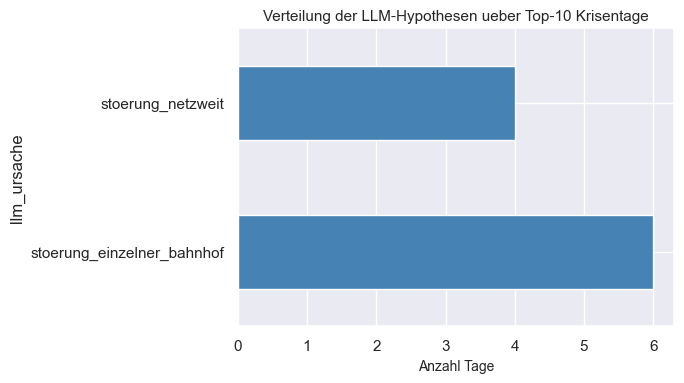

In [10]:
cause_counts = df_results["llm_ursache"].value_counts()
plt.figure(figsize=(7, 4))
cause_counts.plot(kind="barh", color="steelblue")
plt.title("Verteilung der LLM-Hypothesen ueber Top-10 Krisentage", fontsize=11)
plt.xlabel("Anzahl Tage", fontsize=10)
plt.tight_layout()
plt.show()


## Diskussion und Limitationen

- **Keine Ground Truth**: Wir vergleichen die LLM-Hypothesen nicht mit
  tatsächlichen Vorfällen — das wäre nur mit Aufwand (Faktiva-News,
  SBB-Pressemitteilungen) möglich. In der Webapp ergänzen wir später
  News-Headlines aus Factiva als qualitative Validierung.
- **Halluzinations-Risiko**: LLMs können plausibel klingende, aber
  erfundene Erklärungen produzieren. Wir mindern das durch:
  - Niedrige Temperatur (0.2) für Konsistenz
  - Fixe Taxonomie (keine freien Antworten)
  - Explizite Anweisung: "Du erfindest NICHTS"
- **Konfidenz-Skala selbst-eingeschätzt**: "hoch/mittel/niedrig" ist
  die Selbst-Einschätzung des Modells, kein kalibriertes
  Wahrscheinlichkeits-Mass.
- **Aggregations-Verlust**: Tages-Mittel überdeckt lokale Ereignisse
  (z.B. nur Zürich war betroffen). Eine feinere Analyse (pro Stunde,
  pro Region) wäre nächster Schritt.

Trotz dieser Einschränkungen ist die LLM-Klassifikation wertvoll als
**erste Heuristik**: ein Pendler kann den "schlimmsten Tag" verstehen,
ohne 50'000 Datenpunkte zu durchforsten.


## Zusammenfassung Notebook 04

Bonus #4 (LLM-Nutzung) ist erfüllt mit einer **inhaltlich
sinnvollen** Anwendung: qualitative Ursachen-Hypothesen für die
Krisen-Tage. Die Ergebnisse werden in der Streamlit-Webapp im
"Pendler-Insight"-Feature wiederverwendet.


In [11]:
# System-Info (Reproduzierbarkeits-Footer)
import platform
from platform import python_version
from datetime import datetime

print("-----------------------------------")
print(os.name.upper())
print(platform.system(), "|", platform.release())
print("Datetime:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python Version:", python_version())
print("-----------------------------------")


-----------------------------------
NT
Windows | 11
Datetime: 2026-05-20 23:50:33
Python Version: 3.12.10
-----------------------------------
